### 导入数据集

In [181]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification  # 导入用于生成模拟分类数据集的函数

In [182]:
np.random.seed(0)
# 从均值为 0、标准差为 1 的正态分布中生成随机数据。一共生成 200 个样本，每个样本包含 2 个特征。X 的形状为 (200, 2)。
X = np.random.normal(0, 1, size=(200, 2))
# 计算每个样本两个特征的平方和：x₁² + x₂²。当平方和小于 2 时，判断结果为 True；否则为 False。再将 True/False 转换为整数 1/0，作为分类标签。
y = np.array((X[:, 0] ** 2) + (X[:, 1] ** 2) < 2, dtype="int")
y

array([0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0])

In [183]:
X.shape, y.shape

((200, 2), (200,))

In [184]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=233, shuffle=True, stratify=y)

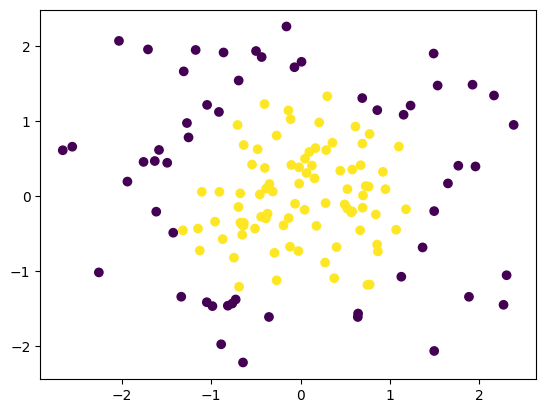

In [185]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.show()

### 多项式逻辑回归（二分类问题）

In [186]:
from sklearn.preprocessing import PolynomialFeatures  # 导入多项式特征转换器

In [187]:
poly = PolynomialFeatures(degree=2)  # 创建二次多项式特征转换器
poly.fit(X_train);  # 使用训练集确定特征转换规则

In [188]:
X2 = poly.transform(X_train)  # 将训练集转换为二次多项式特征
X2t = poly.transform(X_test)  # 使用相同规则转换测试集

In [189]:
from sklearn.linear_model import LogisticRegression  # 导入逻辑回归分类模型

In [190]:
clf = LogisticRegression()  # 创建逻辑回归模型
clf.fit(X2, y_train);  # 使用转换后的训练集训练模型

In [191]:
clf.score(X2, y_train)  # 计算训练集准确率

1.0

In [192]:
clf.score(X2t, y_test)  # 计算测试集准确率

0.9666666666666667

### 多分类 OVR 和 OVO 代码实现

In [193]:
from sklearn import datasets
iris = datasets.load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=666)

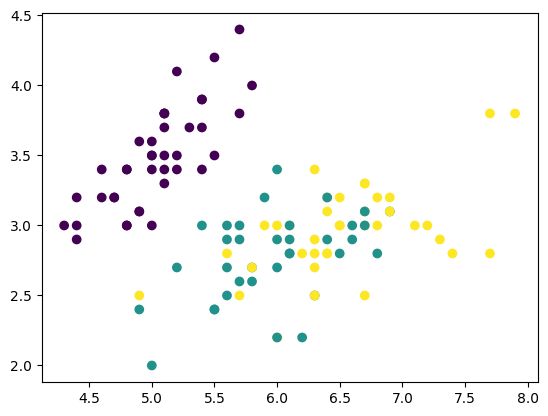

In [194]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.show()

In [195]:
from sklearn.multiclass import OneVsRestClassifier  # 导入一对多（OvR）多分类器
ovr = OneVsRestClassifier(clf)  # 使用 clf 作为基础分类模型，创建一对多分类器
ovr.fit(X_train, y_train)  # 使用训练集训练多分类模型
ovr.score(X_test, y_test)  # 计算模型在测试集上的准确率

0.9736842105263158

In [196]:
from sklearn.multiclass import OneVsOneClassifier  # 导入一对一（OvO）多分类器
ovr = OneVsOneClassifier(clf)  # 使用 clf 作为基础分类模型，创建一对一分类器
ovr.fit(X_train, y_train)  # 使用训练集训练多分类模型
ovr.score(X_test, y_test)  # 计算模型在测试集上的准确率

1.0